# Experimentation with model

### Imports

In [2]:
%load_ext autoreload
%autoreload 2

from transformers import AutoTokenizer, set_seed
import os, torch
import sys, argparse, time
import inspect
import numpy as np
from vllm import LLM, SamplingParams

sys.path.append("src") 
from llama_activate import (
    get_llm,
    run_simulation,
    main, 
    call_visualizations,
    pca_visualize
    
)

from utils.path_manager import PathManager

import utils.metrics as metrics
from utils.path_manager import PathManager
from classes.network import RandomNetwork, SocialDistanceAttachment
import utils.load_personas as lp
import utils.visualization as vis
import utils.reading_in as ri
import warnings

# Suppress annoying warning
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas.io.spss")

# --- Model Configuration ---
llama_model = "meta-llama/Meta-Llama-3.1-8B-Instruct" #bigger model
MODEL_ID = os.environ.get("LLAMA_ID", llama_model)
CACHE_DIR = os.environ.get("TRANSFORMERS_CACHE", None)
SEED = 1234
set_seed(SEED)



/gpfs/home2/choynck/thesis/ABM_based_LLMS/.venv_vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 01-30 20:13:42 [importing.py:44] Triton is installed but 0 active driver(s) found (expected 1). Disabling Triton to prevent runtime errors.
INFO 01-30 20:13:42 [importing.py:68] Triton not installed or not compatible; certain GPU-related functions will not be available.
WARNING 01-30 20:13:46 [interface.py:221] Failed to import from vllm._C: ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


[2026-01-30 20:13:47] INFO config.py:58: PyTorch version 2.9.1 available.


In [3]:
# --- Tokenizer Setup ---
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,  
    cache_dir=CACHE_DIR, 
    use_fast=True, 
)
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

os.environ["VLLM_BATCH_INVARIANT"] = "1"

def get_llm():
    """Set up the vLLM engine."""
    print(f"Loading vLLM model: {MODEL_ID}...")
    llm = LLM(
        model=MODEL_ID,
        dtype="bfloat16",
        trust_remote_code=True,
        gpu_memory_utilization=0.90,
        seed=SEED,
    )
    return llm

# Initialize the model
pipe = get_llm()

Loading vLLM model: meta-llama/Meta-Llama-3.1-8B-Instruct...
INFO 01-30 18:17:05 [utils.py:253] non-default args: {'trust_remote_code': True, 'dtype': 'bfloat16', 'seed': 1234, 'disable_log_stats': True, 'model': 'meta-llama/Meta-Llama-3.1-8B-Instruct'}


RuntimeError: Device string must not be empty

### Set variables

In [4]:
# --- Simulation Variables ---
rounds = 600
num_agents = 100
net = "sda"
seeds = [42]
alpha = 1.0
m = 2
degree = 10
p = 0.3
k = 0
dim = 2
save = False

# Define the states you want to run (["basis", "depressed"])
states = ["basis"] 

# Create the Namespace (mimicking argparse)
args = argparse.Namespace(
    net=net,
    rounds=rounds,
    num_agents=num_agents,
    seed=seeds[0], # Initial default, will be overwritten in loop
    seeds=seeds,   # List of seeds
    m=m,
    p=p,
    k=k,
    depressed=False,
    enforce_ngrams=False,
    alpha=alpha,
    degree=degree,
    dim=dim,
    save=save,
    use_saved_network=0, # Set to integer if updating existing
    directed=False
)

## Get Network Features

Loading network for state 'basis' and seed 42...



/gpfs/home2/choynck/thesis/ABM_based_LLMS/.venv_vllm/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/gpfs/home2/choynck/thesis/ABM_based_LLMS/.venv_vllm/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


PHQ-9 assortativity: 0.1310823422868714
PHQ-9 assortativity: 0.07775020407092814
PHQ-9 assortativity: 0.09109270181793443
PHQ-9 assortativity: 0.07201805651626837
PHQ-9 assortativity: 0.06998494877128747
PHQ-9 assortativity: 0.06897879256167835
PHQ-9 assortativity: 0.06852823872855358
PHQ-9 assortativity: 0.058866000800613126
PHQ-9 assortativity: 0.028397376123850862
PHQ-9 assortativity: 0.05648966563355038


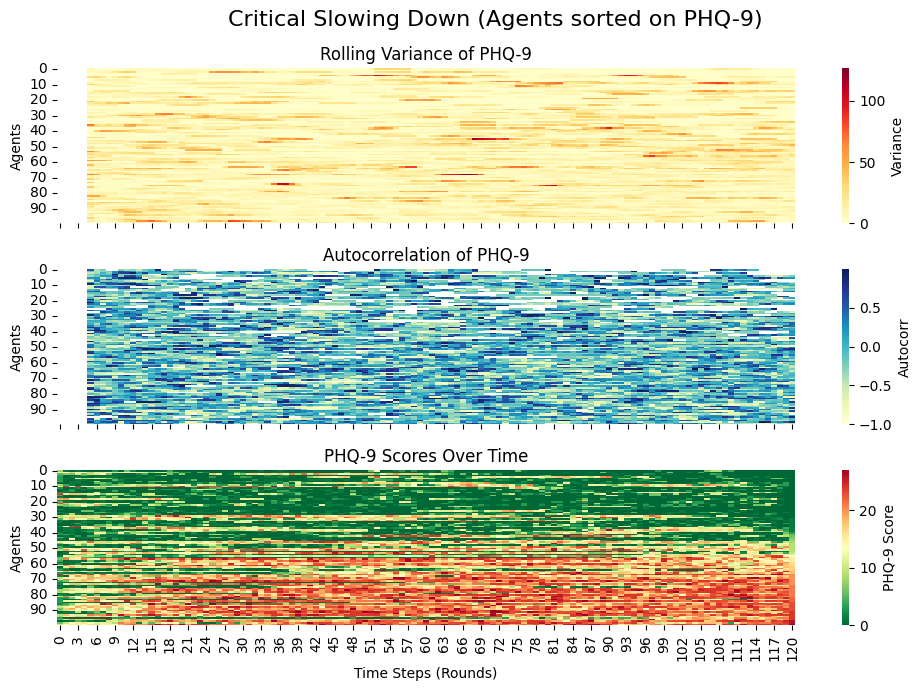

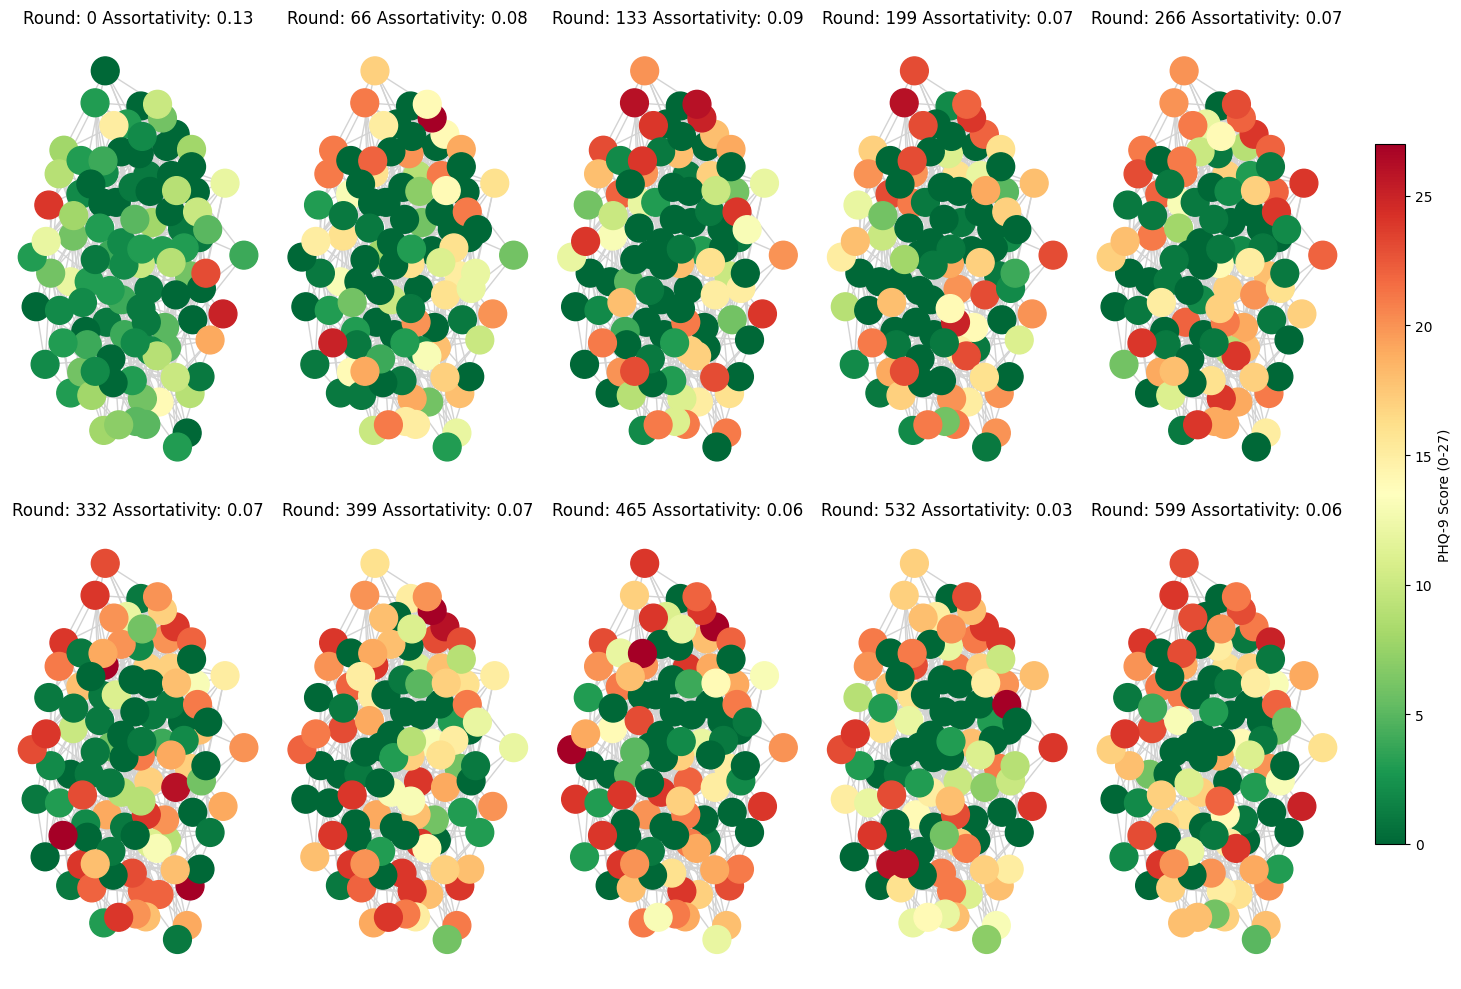

Saving visualizations to directory: plots/networks/basis/sda/undirected/1_0_d10_dim2/rounds600_seed42_N100 filename: _42.png


In [12]:
all_networks_results = main(args, None, states = ["basis"])
network_results = all_networks_results["basis"][0]
network = network_results["network"]
running_fracs = network_results["running_fracs"]
fracs_dist_step = network_results["fracs_dist_step"]
path_manager = PathManager(network=network)

cd_results = metrics.all_agent_phq9_cd(network, window_size=6, shift=6)

# Get paths
data_path = path_manager.get_run_directory(is_plot=False)
plot_path = path_manager.get_run_directory(is_plot=True)
data_filename = path_manager.get_network_filename()
plot_filename = path_manager.get_plot_name()

vis.plot_agent_cd_heatmaps(network, window=6, cd_results=cd_results, metric_name="PHQ-9", path=plot_path, filename=plot_filename, shift=6)

#Maybe bit ugly here but aggregate degree weighted phq9 scores
deg_w_phq9 = metrics.degree_weighted_mean(network)
vis.plot_degree_weighted_phq9(np.array([deg_w_phq9]), plot_path, plot_filename, save=args.save)


call_visualizations(
    network, 
    plot_path, 
    plot_filename, 
    args, 
    running_fracs, 
    fracs_dist_step)

# pca_visualize(all_networks_results, plot_path, plot_filename, args)

Adding PHQ-9 scores as an additional dimension in social space.
Adding age as an additional dimension in social space.
N = 1000 target degree = 30 max possible = 999
Social Distance Attachment network initialized with average degree 29.94
Calculating best minimal value for power law fit
Power-law fit: alpha=22.277658041646575, KS=0.10098947448644313
PHQ-9 assortativity: 0.044018629914293395


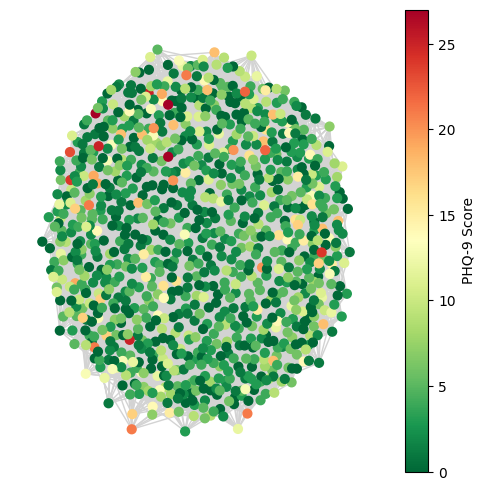

In [10]:
# create network based on args
network, _, _ = run_simulation(args)
vis.print_network_phq9(network, show_fig=True)

PHQ-9 assortativity: -0.03128889033669455


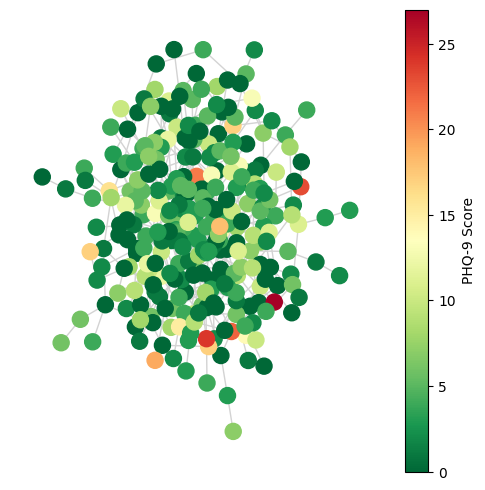

In [4]:
vis.print_network_phq9(network, show_fig=True)


### Generate network and run simulation

In [ ]:
print("Starting simulation via imported function...")
all_networks_results = sim_script.main(args, pipe, states)

<class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>
GENERATOR:  (inputs: Optional[torch.Tensor] = None, generation_config: Optional[transformers.generation.configuration_utils.GenerationConfig] = None, logits_processor: Optional[transformers.generation.logits_process.LogitsProcessorList] = None, stopping_criteria: Optional[transformers.generation.stopping_criteria.StoppingCriteriaList] = None, prefix_allowed_tokens_fn: Optional[Callable[[int, torch.Tensor], list[int]]] = None, synced_gpus: Optional[bool] = None, assistant_model: Optional[ForwardRef('PreTrainedModel')] = None, streamer: Optional[ForwardRef('BaseStreamer')] = None, negative_prompt_ids: Optional[torch.Tensor] = None, negative_prompt_attention_mask: Optional[torch.Tensor] = None, use_model_defaults: Optional[bool] = None, custom_generate: Union[str, Callable, NoneType] = None, **kwargs) -> Union[transformers.generation.utils.GenerateDecoderOnlyOutput, transformers.generation.utils.GenerateEncoderDecoderOutp

Values less than or equal to 0 in data. Throwing out 0 or negative values


Agent 8 FORCED TWEET OUTPUT: TWEET: I feel like I'm drowning in my own thoughts all the time. Just another day, another meaningless conversation on social media #mentalhealthmatters #depression
Agent 28 FORCED TWEET OUTPUT: TWEET: I'm starting a new year, but the same familiar feelings of anxiety creep in. Anyone else feeling stuck in the haze of daily routine? #MDD #anxiety
Agent 20 FORCED TWEET OUTPUT: TWEET: I'm feeling a bit more grounded today, thanks to some yoga practice and a warm bath #MentalHealthMatters
Agent 6 FORCED TWEET OUTPUT: I'm going through a tough week and feeling overwhelmed. Anyone else ever feel this way? #MentalHealthMatters
Agent 16 FORCED TWEET OUTPUT: TWEET: When you finally get to write a good post and get some likes but it's just one lonely post
Agent 25 FORCED TWEET OUTPUT: TWEET: Feeling lost in a sea of uncertainty every day TWEET:
Agent 5 FORCED TWEET OUTPUT: TWEET: 
I've had one night where I felt like I was floating on a cloud
Agent 15 FORCED TWEET O

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Round 3: Mean running fraction of distorted agents: 0.2333, Fraction distorted this step: 0.3333 
Round 4: Mean running fraction of distorted agents: 0.2500, Fraction distorted this step: 0.1429 
Round 5: Mean running fraction of distorted agents: 0.2556, Fraction distorted this step: 0.1538 


#### Visualize CDS

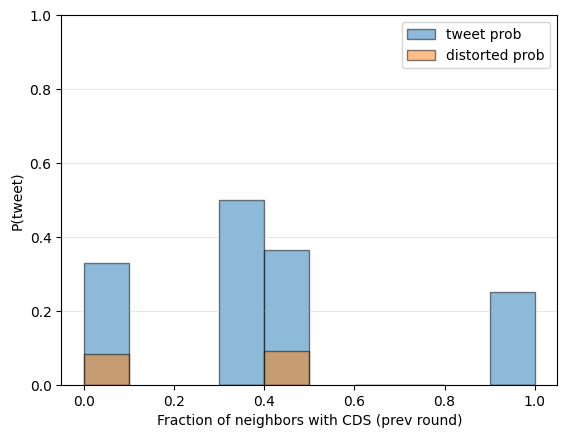

PHQ-9 assortativity: nan


c:\Users\chris\Documents\courses\Thesis\Project\own_setup\.venv\Lib\site-packages\networkx\algorithms\assortativity\mixing.py:113: RuntimeWarning: invalid value encountered in divide
  a = a / a.sum()


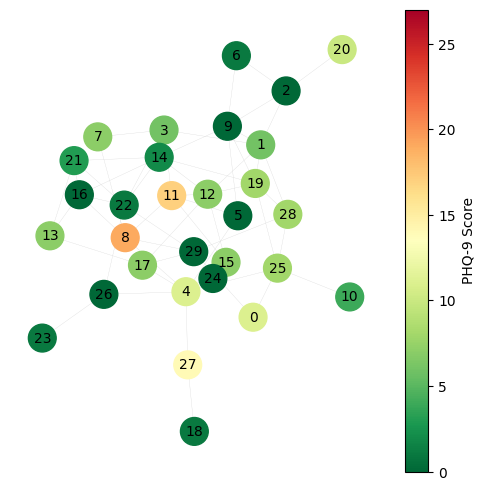

In [ ]:
# Visualizing the first seed of the first state
target_state = states_to_run[0]
run_index = 0 # 0 for the first seed

if target_state in all_networks_results:
    network_data = all_networks_results[target_state][run_index]
    
    network = network_data["network"]
    running_fracs = network_data["running_fracs"]
    fracs_dist_step = network_data["fracs_dist_step"]
    
    # Initialize PathManager with the specific network instance
    path_manager = PathManager(network=network)
    
    data_path = path_manager.get_run_directory(is_plot=False)
    plot_path = path_manager.get_run_directory(is_plot=True)
    data_filename = path_manager.get_network_filename()
    plot_filename = path_manager.get_plot_name()
    
    print(f"Visualizing results for state: {target_state}")
    
    # Print tweet histories
    metrics.print_histories(network, file_dir=data_path, file_name=data_filename, save=args.save)
    
    # Standard visualizations (CDS, frequency, network,)
    call_visualizations(network, plot_path, plot_filename, args, running_fracs, fracs_dist_step)
    
    # PCA Visualization (if large enough simulation is run)
    # pca_visualize(all_networks_results, plot_path, plot_filename, args)
else:
    print(f"No results found for state {target_state}")